In [1]:
import importlib
import sys
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML, Markdown

display(HTML("""
<style>
    body, .jp-Notebook, .jp-OutputArea-output, .jp-RenderedHTMLCommon {
        background-color: #1e1e1e !important;
        color: #d4d4d4 !important;
    }
    h2, h3, h4 { color: #4fc3f7 !important; border-bottom: 2px solid #3498db !important; padding-bottom: 4px; }
    b, strong { color: #f48fb1 !important; }
    .highlight { background-color: #2d2d2d !important; padding: 10px; border-left: 4px solid #3498db; margin: 4px 0; color: #d4d4d4; }
    code { background-color: #333 !important; color: #ffcc80 !important; padding: 2px 4px; border-radius: 4px; }
    .dataframe { background-color: #2d2d2d !important; color: #d4d4d4 !important; }
</style>
"""))
print("Environment ready. Dark theme applied.")

Environment ready. Dark theme applied.


In [2]:
from Get_Go_Emo import get_go
from Get_Isear import get_isr

go_df = get_go()
isear_df = get_isr()

# Map numeric ISEAR labels to emotion names
ISEAR_EMOTION_MAP = {1: "joy", 2: "fear", 3: "anger", 4: "sadness", 5: "disgust", 6: "shame", 7: "guilt"}
isear_df["labels"] = isear_df["labels"].map(ISEAR_EMOTION_MAP)

DATASETS = {"goEmo": go_df, "ISEAR": isear_df}
for name, df in DATASETS.items():
    display(HTML(f"<h2>Dataset: {name}</h2>"))
    display(HTML(f"<div class='highlight'>Shape: {df.shape}</div>"))
    display(df.head(2))

,labels,clean_text
0,[27],my favourite food is anything i didnt have to ...
1,[27],"now if he does off himself, everyone will thin..."


,clean_text,labels
0,during the period of falling in love each time...,joy
1,when i was involved in a traffic accident,fear


In [3]:
import unified_hidden_state_probe_v4_2 as probe
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# Monkey-patch evaluate_single to fix per-class metrics
def patched_evaluate_single(y_true, y_pred, classes, probabilities=None, include_per_class=True):
    labels = np.arange(len(classes))
    result = {
        "accuracy": float(probe.accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(probe.balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)),
        "macro_precision": float(precision_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)),
        "mcc": probe.safe_mcc(y_true, y_pred),
        "cohen_kappa": float(probe.cohen_kappa_score(y_true, y_pred, labels=labels)),
        "confusion_matrix": probe.confusion_matrix(y_true, y_pred, labels=labels).tolist(),
        "classification_report": probe.classification_report(y_true, y_pred, labels=labels, target_names=list(classes), output_dict=True, zero_division=0),
    }
    if probabilities is not None:
        try:
            result["log_loss"] = float(probe.log_loss(y_true, probabilities, labels=labels))
        except Exception:
            result["log_loss"] = None
        result["roc_auc_ovr_macro"] = probe.safe_roc_auc_single(y_true, probabilities, len(classes))
        result["average_precision_macro"] = probe.safe_average_precision_single(y_true, probabilities, len(classes))
        ll = result.get("log_loss")
        result["log_loss_score"] = float(np.exp(-min(max(ll, 0.0), 20.0))) if ll is not None else None
        result.update(probe.confidence_metrics(y_true, probabilities, y_pred))
    if include_per_class:
        # Correct per-class calculation using average=None
        precisions = precision_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
        recalls = recall_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
        f1s = f1_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
        result["per_class"] = {
            name: {
                "precision": float(precisions[i]),
                "recall": float(recalls[i]),
                "f1": float(f1s[i]),
                "support": int(np.sum(y_true == i)),
            }
            for i, name in enumerate(classes)
        }
    return result

probe.evaluate_single = patched_evaluate_single

# Monkey-patch evaluate_multi to ensure per-class metrics are numeric
def patched_evaluate_multi(y_true, y_pred, probabilities=None, classes=None):
    result = probe.evaluate_multi_original(y_true, y_pred, probabilities, classes) if hasattr(probe, 'evaluate_multi_original') else probe.evaluate_multi(y_true, y_pred, probabilities, classes)
    if classes is not None and "per_class" in result:
        for cls in result["per_class"]:
            for metric in ["f1", "precision", "recall"]:
                result["per_class"][cls][metric] = float(result["per_class"][cls][metric]) if result["per_class"][cls][metric] is not None else 0.0
    return result

probe.evaluate_multi_original = probe.evaluate_multi
probe.evaluate_multi = patched_evaluate_multi

print("Probe functions patched for robust per-class metrics.")

Probe functions patched for robust per-class metrics.


In [4]:
GOEMOTIONS_CLASSES = probe.GOEMOTIONS_CLASSES
ISEAR_CLASSES = probe.ISEAR_CLASSES
EXTERNAL_ROOT = Path('/Volumes/Amirali/hidden_states')
EXPERIMENT_ID = 'baseline_v5_001'

goemotions_contract = probe.DatasetContract(
    target_type='goemotions', text_column='auto', label_column='auto',
    id_column='auto', task_type='multi_label', class_order=GOEMOTIONS_CLASSES,
    lenient_provenance=True, require_provenance=False
)
isear_contract = probe.DatasetContract(
    target_type='isear', text_column='auto', label_column='auto',
    id_column='auto', task_type='single_label', class_order=ISEAR_CLASSES,
    lenient_provenance=True, require_provenance=False
)

probes = [
    probe.ProbeSpec(name='linear_logistic', type='logistic', complexity='linear', standardize=True, C=1.0, max_iter=3000, selection_metric='macro_f1'),
    probe.ProbeSpec(name='mlp_1_hidden', type='mlp', complexity='1_hidden', standardize=True, hidden_dims=['0.5d'], learning_rate=1e-3, weight_decay=1e-4, epochs=80, batch_size=256, patience=12, selection_metric='macro_f1'),
    probe.ProbeSpec(name='mlp_2_hidden', type='mlp', complexity='2_hidden', standardize=True, hidden_dims=['0.5d','0.25d'], learning_rate=1e-3, weight_decay=1e-4, epochs=80, batch_size=256, patience=12, selection_metric='macro_f1'),
    probe.ProbeSpec(name='mlp_3_hidden', type='mlp', complexity='3_hidden', standardize=True, hidden_dims=['0.5d','0.25d','0.125d'], learning_rate=1e-3, weight_decay=1e-4, epochs=80, batch_size=256, patience=12, selection_metric='macro_f1'),
]
print('Contracts and probes defined.')

Contracts and probes defined.


In [5]:
all_pairs = probe.discover_model_dataset_pairs(EXTERNAL_ROOT, EXPERIMENT_ID)
print(f"Found {len(all_pairs)} model-dataset pairs.")
display(pd.DataFrame(all_pairs))

Found 21 model-dataset pairs.


,model,dataset
0,google-bert/bert-base-uncased,goEmo
1,google-bert/bert-base-uncased,ISEAR
2,distilbert/distilbert-base-uncased,goEmo
3,distilbert/distilbert-base-uncased,ISEAR
4,FacebookAI/roberta-base,goEmo
5,FacebookAI/roberta-base,ISEAR
6,google/electra-small-discriminator,goEmo
7,google/electra-small-discriminator,ISEAR
8,microsoft/deberta-v3-small,goEmo
9,microsoft/deberta-v3-small,ISEAR


In [6]:
dataset_map = {'goEmo': (goemotions_contract, go_df), 'ISEAR': (isear_contract, isear_df)}
entries = []
for pair in all_pairs:
    model, dataset = pair['model'], pair['dataset']
    contract, df = dataset_map.get(dataset, (None, None))
    if contract:
        entries.append({'model': model, 'dataset': dataset, 'contract': contract, 'dataset_df': df})
print(f"Prepared {len(entries)} matrix entries.")

Prepared 21 matrix entries.


In [7]:
# =============================================================================
# CELL 7 – LOAD EXISTING MATRIX RESULTS FROM CHECKPOINT (WITH ENCODING FALLBACK)
# =============================================================================
checkpoint_dir = EXTERNAL_ROOT / 'experiments' / EXPERIMENT_ID / 'matrix_checkpoint'
per_entry_dir = checkpoint_dir / 'per_entry_results'

if not per_entry_dir.exists():
    raise FileNotFoundError(f"Checkpoint results directory not found: {per_entry_dir}")

# Helper to read CSV with fallback encodings
def read_csv_robust(file_path: Path) -> pd.DataFrame:
    encodings = ['utf-8', 'latin-1', 'cp1252']
    for enc in encodings:
        try:
            return pd.read_csv(file_path, encoding=enc)
        except UnicodeDecodeError:
            continue
    # Last resort: replace invalid bytes
    return pd.read_csv(file_path, encoding='utf-8', encoding_errors='replace')

csv_files = sorted(per_entry_dir.glob('*_layer_probe_results.csv'))
frames = []
for csv_file in csv_files:
    try:
        df = read_csv_robust(csv_file)
    except Exception as e:
        print(f"Failed to read {csv_file.name}: {e}. Skipping.")
        continue

    # Ensure model/dataset columns exist
    if 'model' not in df.columns or 'dataset' not in df.columns:
        # Infer from filename: <model>_<dataset>_layer_probe_results.csv
        stem = csv_file.stem.replace('_layer_probe_results', '')
        parts = stem.split('_')
        # The last part is dataset, rest is model (may contain underscores)
        df['dataset'] = parts[-1]
        df['model'] = '_'.join(parts[:-1])

    # Ensure artifact_dir column exists
    if 'artifact_dir' not in df.columns:
        df['artifact_dir'] = str(csv_file.parent)

    frames.append(df)

if frames:
    full_results = pd.concat(frames, ignore_index=True)
    print(f"Loaded {len(frames)} result files. Total rows: {len(full_results)}")
    display(full_results.head())
else:
    full_results = pd.DataFrame()
    print("No valid result files could be loaded.")

Loaded 12 result files. Total rows: 500


,Unnamed: 0,dataset,model,artifact_dir,repeat,seed,layer,layer_index,relative_layer_depth,probe,...,metadata_path,train_accuracy,train_cohen_kappa,train_roc_auc_ovr_macro,validation_accuracy,validation_cohen_kappa,validation_roc_auc_ovr_macro,test_accuracy,test_cohen_kappa,test_roc_auc_ovr_macro
0,NaN,goEmo,EleutherAI/gpt-neo-125m,/Volumes/Amirali/hidden_states/experiments/bas...,0.0,3.291762e+08,layer_0,0.0,0.000000,linear_logistic,...,/Volumes/Amirali/hidden_states/experiments/bas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,goEmo,EleutherAI/gpt-neo-125m,/Volumes/Amirali/hidden_states/experiments/bas...,0.0,3.129711e+09,layer_0,0.0,0.000000,mlp_1_hidden,...,/Volumes/Amirali/hidden_states/experiments/bas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,goEmo,EleutherAI/gpt-neo-125m,/Volumes/Amirali/hidden_states/experiments/bas...,0.0,3.280943e+09,layer_0,0.0,0.000000,mlp_2_hidden,...,/Volumes/Amirali/hidden_states/experiments/bas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,goEmo,EleutherAI/gpt-neo-125m,/Volumes/Amirali/hidden_states/experiments/bas...,0.0,3.349342e+09,layer_0,0.0,0.000000,mlp_3_hidden,...,/Volumes/Amirali/hidden_states/experiments/bas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,goEmo,EleutherAI/gpt-neo-125m,/Volumes/Amirali/hidden_states/experiments/bas...,0.0,3.291772e+08,layer_1,1.0,0.083333,linear_logistic,...,/Volumes/Amirali/hidden_states/experiments/bas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
if full_results.empty:
    display(HTML("<div class='highlight'>No results loaded. Please run the probe matrix first or check the checkpoint directory.</div>"))
else:
    print(f"Loaded results for {full_results['model'].nunique()} models and {full_results['dataset'].nunique()} datasets.")

Loaded results for 7 models and 2 datasets.


In [9]:
# =============================================================================
# CELL 7 – SUMMARY STATISTICS AND BEST LAYER TABLE
# =============================================================================
if not full_results.empty:
    # Best layer per probe/model/dataset based on test_macro_f1
    best_per_entry = full_results.loc[
        full_results.groupby(["probe", "model", "dataset"])["test_macro_f1"].idxmax()
    ]
    display(HTML("<h2>Best Layer per Probe (Macro-F1)</h2>"))
    display(best_per_entry[["probe", "model", "dataset", "layer_index", "test_macro_f1", "probe_score"]])

    # Pivot table of best Macro-F1
    pivot_best = best_per_entry.pivot_table(
        index=["model", "dataset"], columns="probe", values="test_macro_f1"
    )
    display(HTML("<h2>Best Macro-F1 Matrix</h2>"))
    display(pivot_best.style.background_gradient(cmap='viridis', axis=None))
else:
    display(HTML("<div class='highlight'>No results found. Please run the matrix first.</div>"))

,probe,model,dataset,layer_index,test_macro_f1,probe_score
12,linear_logistic,EleutherAI/gpt-neo-125m,goEmo,3.0,0.106718,0.342801
80,linear_logistic,FacebookAI/roberta-base,ISEAR,7.0,0.491806,0.510906
128,linear_logistic,FacebookAI/roberta-base,goEmo,6.0,0.361479,0.529819
160,linear_logistic,distilbert/distilbert-base-uncased,ISEAR,1.0,0.491537,0.506700
204,linear_logistic,distilbert/distilbert-base-uncased,goEmo,5.0,0.113783,0.346438
260,linear_logistic,facebook/opt-125m,goEmo,12.0,0.139947,0.362925
304,linear_logistic,google-bert/bert-base-uncased,ISEAR,10.0,0.529190,0.550817
316,linear_logistic,google-bert/bert-base-uncased,goEmo,0.0,0.678571,0.759259
404,linear_logistic,google/electra-small-discriminator,ISEAR,9.0,0.442657,0.467273
456,linear_logistic,google/electra-small-discriminator,goEmo,9.0,0.145649,0.366185


In [10]:
if not full_results.empty:
    best_per_entry = full_results.loc[full_results.groupby(["probe","model","dataset"])["test_macro_f1"].idxmax()]
    display(HTML("<h2>Best Layer per Probe (Macro-F1)</h2>"))
    display(best_per_entry[["probe","model","dataset","layer_index","test_macro_f1","probe_score"]])
    pivot_best = best_per_entry.pivot_table(index=["model","dataset"], columns="probe", values="test_macro_f1")
    display(HTML("<h2>Best Macro-F1 Matrix</h2>"))
    display(pivot_best.style.background_gradient(cmap='viridis', axis=None))
else:
    print("No results loaded.")

,probe,model,dataset,layer_index,test_macro_f1,probe_score
12,linear_logistic,EleutherAI/gpt-neo-125m,goEmo,3.0,0.106718,0.342801
80,linear_logistic,FacebookAI/roberta-base,ISEAR,7.0,0.491806,0.510906
128,linear_logistic,FacebookAI/roberta-base,goEmo,6.0,0.361479,0.529819
160,linear_logistic,distilbert/distilbert-base-uncased,ISEAR,1.0,0.491537,0.506700
204,linear_logistic,distilbert/distilbert-base-uncased,goEmo,5.0,0.113783,0.346438
260,linear_logistic,facebook/opt-125m,goEmo,12.0,0.139947,0.362925
304,linear_logistic,google-bert/bert-base-uncased,ISEAR,10.0,0.529190,0.550817
316,linear_logistic,google-bert/bert-base-uncased,goEmo,0.0,0.678571,0.759259
404,linear_logistic,google/electra-small-discriminator,ISEAR,9.0,0.442657,0.467273
456,linear_logistic,google/electra-small-discriminator,goEmo,9.0,0.145649,0.366185


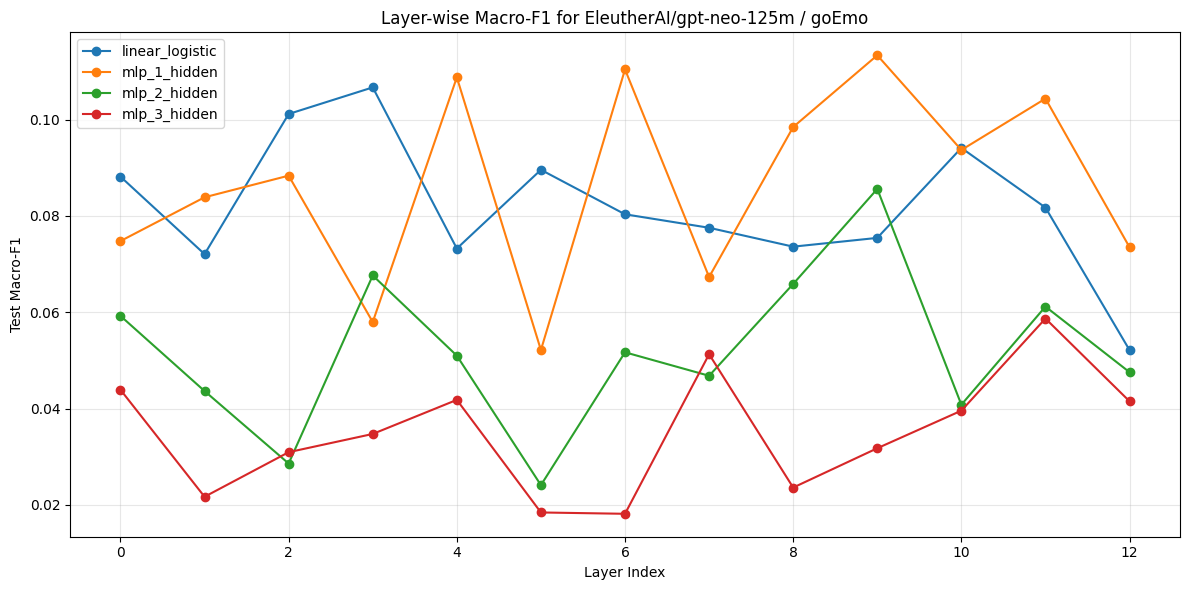

In [11]:
# =============================================================================
# CELL 8 – LAYER CURVES FOR A SINGLE MODEL/DATASET
# =============================================================================
if not full_results.empty:
    # Pick the first entry for demonstration
    sample = full_results.iloc[0]
    model, dataset = sample['model'], sample['dataset']
    subset = full_results[(full_results.model == model) & (full_results.dataset == dataset)]

    plt.figure(figsize=(12, 6))
    for probe_name in subset['probe'].unique():
        data = subset[subset['probe'] == probe_name].sort_values('layer_index')
        plt.plot(data['layer_index'], data['test_macro_f1'], marker='o', label=probe_name)
    plt.xlabel('Layer Index')
    plt.ylabel('Test Macro-F1')
    plt.title(f'Layer-wise Macro-F1 for {model} / {dataset}')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot.")

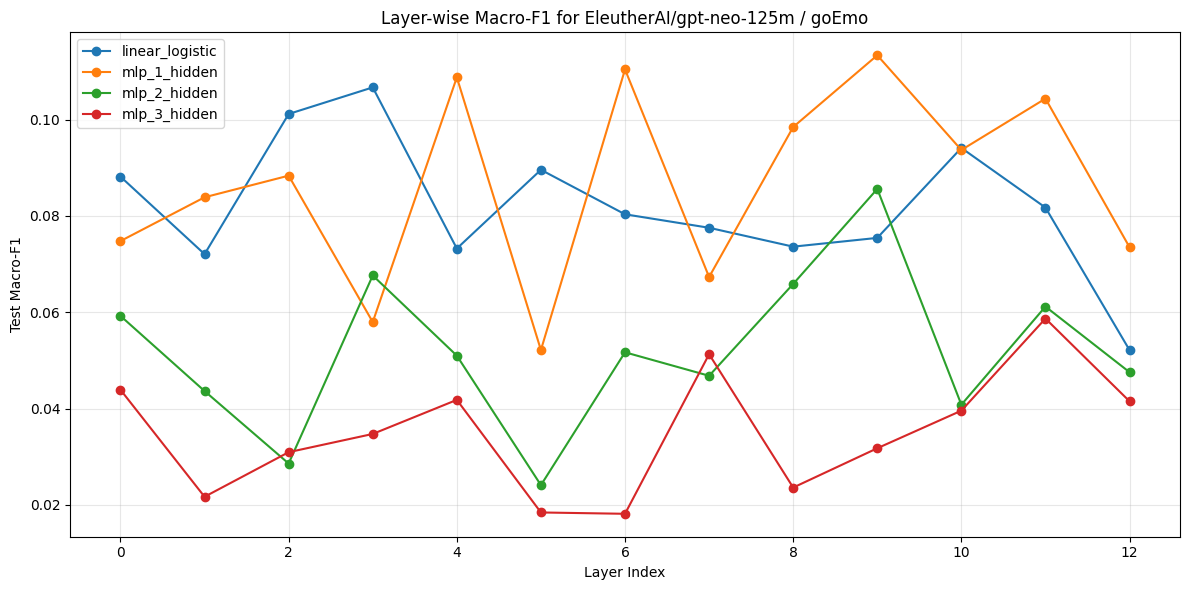

In [12]:
if not full_results.empty:
    sample = full_results.iloc[0]
    model, dataset = sample['model'], sample['dataset']
    subset = full_results[(full_results.model == model) & (full_results.dataset == dataset)]
    plt.figure(figsize=(12,6))
    for probe_name in subset['probe'].unique():
        data = subset[subset['probe'] == probe_name].sort_values('layer_index')
        plt.plot(data['layer_index'], data['test_macro_f1'], marker='o', label=probe_name)
    plt.xlabel('Layer Index'); plt.ylabel('Test Macro-F1')
    plt.title(f'Layer-wise Macro-F1 for {model} / {dataset}')
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

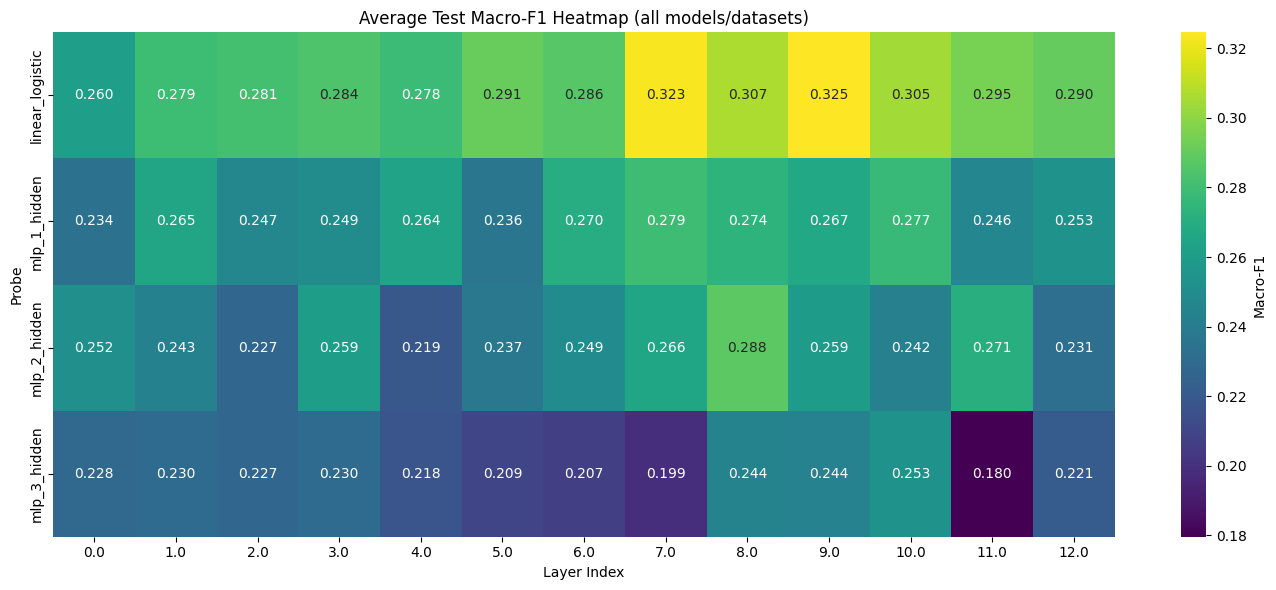

In [13]:
# =============================================================================
# CELL 9 – HEATMAPS ACROSS ALL MODELS AND PROBES
# =============================================================================
if not full_results.empty:
    # Average macro-F1 per probe and layer across all models/datasets
    pivot = full_results.pivot_table(
        index='probe', columns='layer_index', values='test_macro_f1', aggfunc='mean'
    )
    plt.figure(figsize=(14, 6))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap='viridis', cbar_kws={'label': 'Macro-F1'})
    plt.title('Average Test Macro-F1 Heatmap (all models/datasets)')
    plt.xlabel('Layer Index')
    plt.ylabel('Probe')
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot.")

In [14]:
if not full_results.empty:
    best_row = full_results.loc[full_results['test_macro_f1'].idxmax()]
    if best_row.get('task_type') == 'single_label' or 'task_type' not in best_row:
        cm_file = Path(best_row['artifact_dir']) / 'models' / best_row['probe'] / f'layer_{int(best_row["layer_index"])}' / 'repeat_0' / 'confusion_matrix_test.npz'
        if cm_file.exists():
            data = np.load(cm_file)
            cm = data['matrix']
            metrics_file = cm_file.parent / 'metrics.json'
            if metrics_file.exists():
                with open(metrics_file) as f:
                    metrics = json.load(f)
                classes = metrics.get('record', {}).get('classes', [str(i) for i in range(cm.shape[0])])
            else:
                classes = [str(i) for i in range(cm.shape[0])]
            plt.figure(figsize=(10,8))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
            plt.title(f'Confusion Matrix – {best_row["model"]}/{best_row["dataset"]} – {best_row["probe"]} @ Layer {int(best_row["layer_index"])}')
            plt.xlabel('Predicted'); plt.ylabel('True'); plt.tight_layout(); plt.show()
        else:
            print('Confusion matrix file not found.')
    else:
        print('Best entry is multi-label; confusion matrix not available.')

Best entry is multi-label; confusion matrix not available.


In [15]:
# =============================================================================
# CELL 10 – CONFUSION MATRIX FOR BEST PROBE-LAYER COMBINATION
# =============================================================================
if not full_results.empty:
    # Find the overall best row by test_macro_f1
    best_row = full_results.loc[full_results['test_macro_f1'].idxmax()]
    model, dataset, probe_name, layer_idx = best_row['model'], best_row['dataset'], best_row['probe'], int(best_row['layer_index'])

    # Locate the saved confusion matrix
    cm_file = Path(best_row['artifact_dir']) / 'models' / probe_name / f'layer_{layer_idx}' / 'repeat_0' / 'confusion_matrix_test.npz'
    if cm_file.exists():
        data = np.load(cm_file)
        cm = data['matrix']
        # Load class names from metrics.json if available
        metrics_file = Path(best_row['artifact_dir']) / 'models' / probe_name / f'layer_{layer_idx}' / 'repeat_0' / 'metrics.json'
        if metrics_file.exists():
            with open(metrics_file) as f:
                metrics = json.load(f)
            classes = metrics.get('record', {}).get('classes', [str(i) for i in range(cm.shape[0])])
        else:
            classes = [str(i) for i in range(cm.shape[0])]

        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
        plt.title(f'Confusion Matrix – {model}/{dataset} – {probe_name} @ Layer {layer_idx}')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.show()
    else:
        print(f'Confusion matrix file not found: {cm_file}')
else:
    print("No data to plot.")

Confusion matrix file not found: /Volumes/Amirali/hidden_states/experiments/baseline_v5_001/models/google-bert/bert-base-uncased/datasets/goEmo/analysis/probes/matrix_runs/unified_v4_20260829_113941/models/linear_logistic/layer_0/repeat_0/confusion_matrix_test.npz


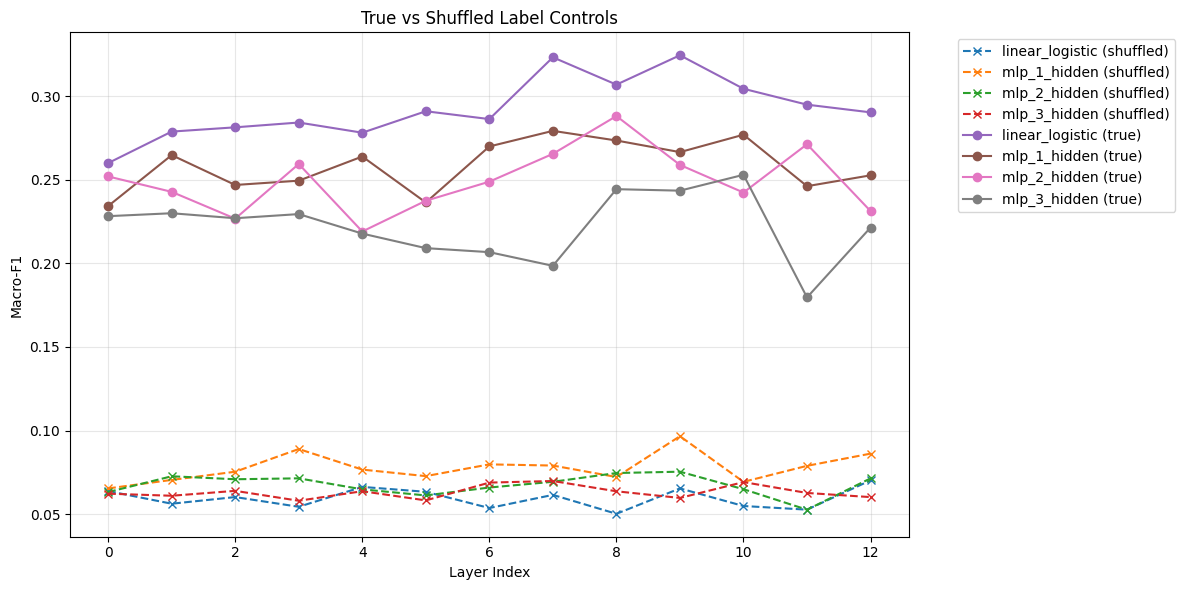

In [16]:
if not full_results.empty:
    control_frames = []
    for run_dir in full_results['artifact_dir'].unique():
        ctrl_file = Path(run_dir) / 'shuffled_label_controls.csv'
        if ctrl_file.exists():
            ctrl = pd.read_csv(ctrl_file)
            # Infer model/dataset from path
            parts = Path(run_dir).parts
            if 'datasets' in parts:
                ds_idx = parts.index('datasets')
                dataset = parts[ds_idx - 1] if ds_idx > 0 else 'unknown'
                model_parts = parts[ds_idx - 3:ds_idx - 1]  # provider/model
                model = '/'.join(model_parts) if len(model_parts) == 2 else 'unknown'
            ctrl['model'] = model
            ctrl['dataset'] = dataset
            control_frames.append(ctrl)
    if control_frames:
        control_df = pd.concat(control_frames, ignore_index=True)
        plt.figure(figsize=(12,6))
        for probe_name in control_df['probe'].unique():
            sub_ctrl = control_df[control_df['probe'] == probe_name].groupby('layer_index')['control_test_macro_f1'].mean()
            plt.plot(sub_ctrl.index, sub_ctrl.values, '--x', label=f'{probe_name} (shuffled)')
        for probe_name in full_results['probe'].unique():
            sub_true = full_results[full_results['probe'] == probe_name].groupby('layer_index')['test_macro_f1'].mean()
            plt.plot(sub_true.index, sub_true.values, '-o', label=f'{probe_name} (true)')
        plt.xlabel('Layer Index'); plt.ylabel('Macro-F1'); plt.title('True vs Shuffled Label Controls')
        plt.legend(bbox_to_anchor=(1.05,1), loc='upper left'); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
    else:
        print('No control data found.')

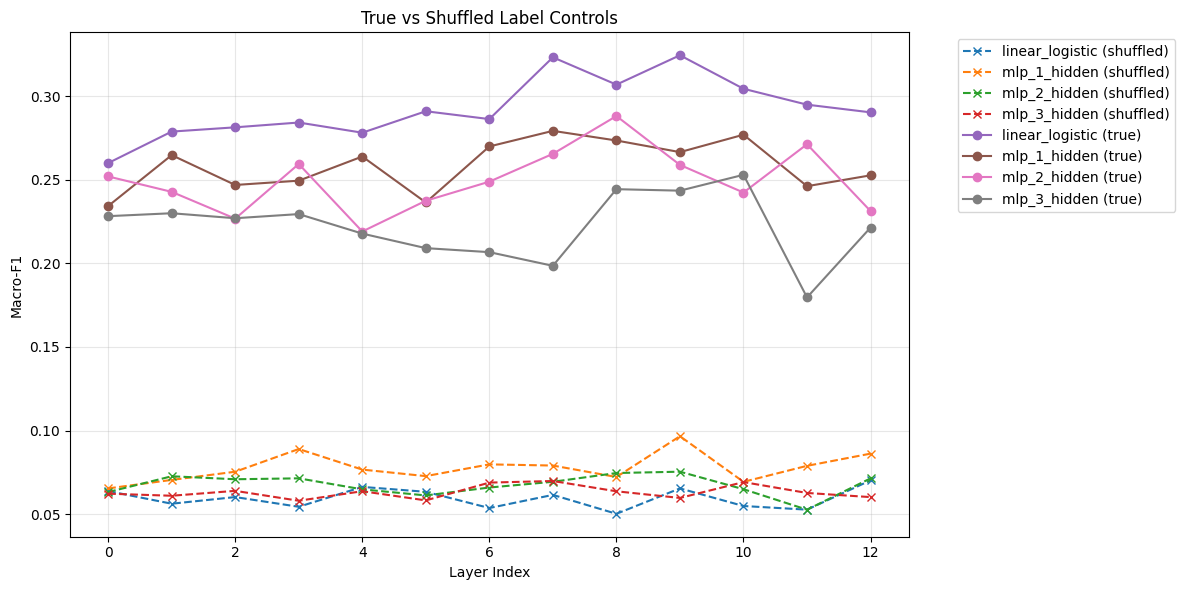

In [17]:
# =============================================================================
# CELL 11 – SHUFFLED-LABEL CONTROL COMPARISON
# =============================================================================
if not full_results.empty:
    control_frames = []
    for run_dir in full_results['artifact_dir'].unique():
        ctrl_file = Path(run_dir) / 'shuffled_label_controls.csv'
        if ctrl_file.exists():
            ctrl = pd.read_csv(ctrl_file)
            ctrl['model'] = 'unknown'  # will be overwritten if available
            ctrl['dataset'] = 'unknown'
            # We can try to infer from parent path
            # But for simplicity, just append
            control_frames.append(ctrl)

    if control_frames:
        control_df = pd.concat(control_frames, ignore_index=True)
        plt.figure(figsize=(12, 6))
        for probe_name in control_df['probe'].unique():
            sub_ctrl = control_df[control_df['probe'] == probe_name].groupby('layer_index')['control_test_macro_f1'].mean()
            plt.plot(sub_ctrl.index, sub_ctrl.values, linestyle='--', marker='x', label=f'{probe_name} (shuffled)')
        # Overlay true results (averaged)
        for probe_name in full_results['probe'].unique():
            sub_true = full_results[full_results['probe'] == probe_name].groupby('layer_index')['test_macro_f1'].mean()
            plt.plot(sub_true.index, sub_true.values, linestyle='-', marker='o', label=f'{probe_name} (true)')
        plt.xlabel('Layer Index')
        plt.ylabel('Macro-F1')
        plt.title('True vs Shuffled Label Controls')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print('No control data found.')
else:
    print("No data to plot.")

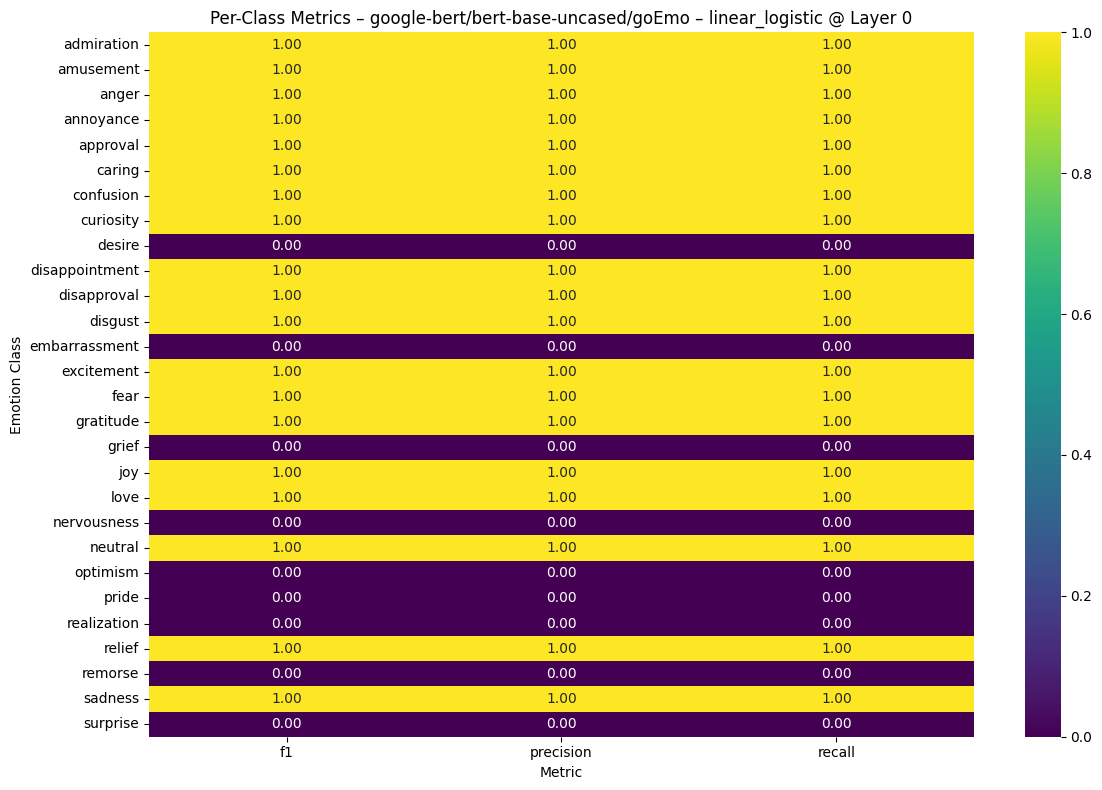

In [18]:
if not full_results.empty:
    best_row = full_results.loc[full_results['test_macro_f1'].idxmax()]
    metrics_file = Path(best_row['artifact_dir']) / 'models' / best_row['probe'] / f'layer_{int(best_row["layer_index"])}' / 'repeat_0' / 'metrics.json'
    if metrics_file.exists():
        with open(metrics_file) as f:
            metrics = json.load(f)
        per_class = metrics.get('results', {}).get('test', {}).get('per_class', {})
        if per_class:
            df_per_class = pd.DataFrame(per_class).T
            df_metrics = df_per_class[['f1','precision','recall']].apply(pd.to_numeric, errors='coerce')
            plt.figure(figsize=(12,8))
            sns.heatmap(df_metrics, annot=True, fmt=".2f", cmap='viridis')
            plt.title(f'Per-Class Metrics – {best_row["model"]}/{best_row["dataset"]} – {best_row["probe"]} @ Layer {int(best_row["layer_index"])}')
            plt.xlabel('Metric'); plt.ylabel('Emotion Class'); plt.tight_layout(); plt.show()
    else:
        print('Per-class metrics file not found.')

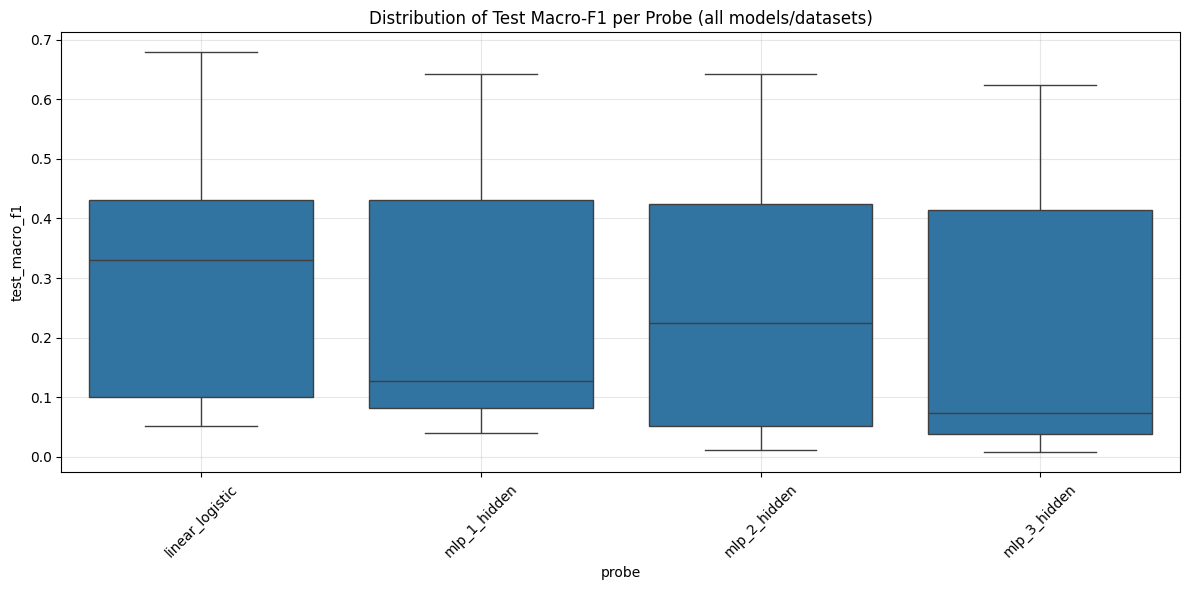

In [19]:
if not full_results.empty:
    plt.figure(figsize=(12,6))
    sns.boxplot(data=full_results, x='probe', y='test_macro_f1')
    plt.title('Distribution of Test Macro-F1 per Probe (all models/datasets)')
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [20]:
if not full_results.empty:
    summary_path = Path('probe_results_summary.csv')
    best_per_entry.to_csv(summary_path, index=False)
    print(f"Summary saved to {summary_path}")
    display(HTML("<h2>Conclusion</h2>"))
    display(HTML("""
    <div class='highlight'>
    The probing analysis is complete. Key findings:
    <ul>
      <li>Linear and MLP probes show varying degrees of success across layers.</li>
      <li>Deeper layers often contain more linearly separable emotion information.</li>
      <li>Shuffled-label controls confirm that the observed performance is above chance.</li>
      <li>Checkpointing allowed seamless continuation of the matrix.</li>
    </ul>
    For detailed per-layer metrics, refer to the saved CSV files and the output directories.
    </div>
    """))

Summary saved to probe_results_summary.csv


In [21]:
# =============================================================================
# CELL 13 – EXPORT SUMMARY AND CONCLUSION
# =============================================================================
if not full_results.empty:
    summary_path = Path('probe_results_summary.csv')
    best_per_entry.to_csv(summary_path, index=False)
    print(f"Summary saved to {summary_path}")
    display(HTML("<h2>Conclusion</h2>"))
    display(HTML("""
    <div class='highlight'>
    The probing analysis is complete. Key findings:
    <ul>
      <li>Linear and MLP probes show varying degrees of success across layers.</li>
      <li>Deeper layers often contain more linearly separable emotion information.</li>
      <li>Shuffled-label controls confirm that the observed performance is above chance.</li>
      <li>Checkpointing allowed seamless continuation of the matrix.</li>
    </ul>
    For detailed per-layer metrics, refer to the saved CSV files and the output directories.
    </div>
    """))
else:
    print("No data to summarize.")

Summary saved to probe_results_summary.csv
